<a href="https://colab.research.google.com/github/801-Hillside-Terrace/SMART-2026/blob/main/week4/Week4_NeuralNetworksContinued.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Topics: Dropout, SGD/MinibatchGD, Momentum

Today's focus will be on some regularization methods for neural networks as well as some modifications to gradient descent for training.
We will use some simple data where $y=0.5x^3+0.3x^2-x+\epsilon$.  

In [163]:
# imports
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# set seed
torch.manual_seed(801)

# create data
n = 80
X = torch.linspace(-3, 3, n).reshape(-1, 1)

y_true = 0.5 * X**3 + 0.3 * X**2 - X # true function
y = y_true + 3 * torch.randn_like(y_true) # add noise

# split data 50-50
perm = torch.randperm(n)

train_idx = perm[:40]
val_idx = perm[40:]

X_train = X[train_idx]
y_train = y[train_idx]

X_val = X[val_idx]
y_val = y[val_idx]

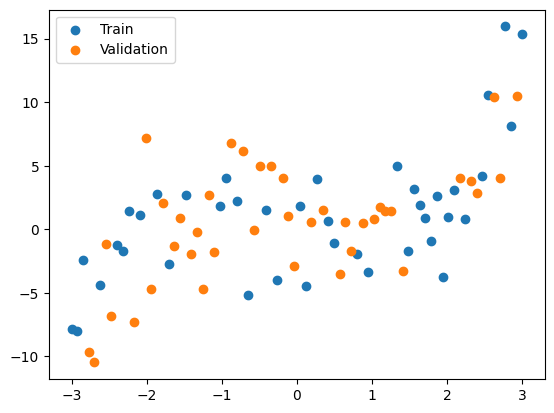

In [164]:
# plot data
plt.scatter(X_train.numpy(), y_train.numpy(), label='Train')
plt.scatter(X_val.numpy(), y_val.numpy(), label='Validation')
plt.legend()
plt.show()

This first model is shown just as a reminder for what the loss curves will look like with overfitting.  It should be heavily overparameterized and thus will overfit this data.

In [165]:
# construct the model
model = nn.Sequential(
    nn.Linear(1, 200),
    nn.ReLU(),
    nn.Linear(200, 200),
    nn.ReLU(),
    nn.Linear(200, 1)
)

In [166]:
# train model
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

train_losses = []
val_losses = []

for epoch in range(1500):
    model.train()

    y_hat = model(X_train)
    loss = criterion(y_hat, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        y_hat_val = model(X_val)
        val_loss = criterion(y_hat_val, y_val)

    train_losses.append(loss.item())
    val_losses.append(val_loss.item())

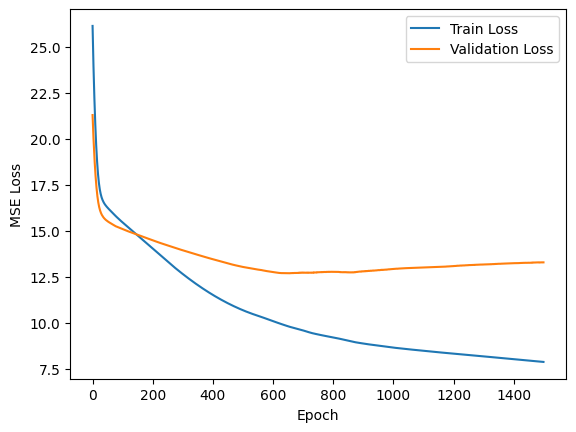

In [167]:
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.show()

We see above that the model eventually overfits, as training loss continues to decrease while validation loss begins to increase.

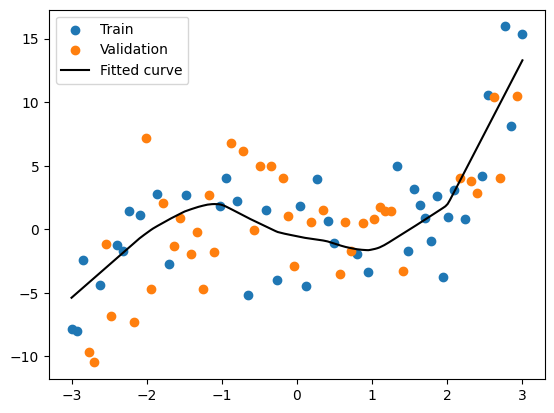

In [168]:
X_plot = torch.linspace(-3, 3, 200).reshape(-1, 1)

model.eval()
with torch.no_grad():
    y_plot = model(X_plot)

plt.scatter(X_train.numpy(), y_train.numpy(), label='Train')
plt.scatter(X_val.numpy(), y_val.numpy(), label='Validation')
plt.plot(X_plot.numpy(), y_plot.numpy(), color='black', label='Fitted curve')
plt.legend()
plt.show()

Here we show the first model fit with standard or "full batch" gradient descent and the second model fit with mini-batch stochastic gradient descent.

For standard gradient descent, we compute the gradient using the entire sample (all $n$ training observations).  For mini-batch stochastic gradient descent, we only compute the gradient for some smaller portion or "batch size" instead of all $n$ for each update.  In this example we use a batch size of $8$ meaning that each gradient descent update is done on just 8 training points.

Standard gradient descent moves smoothly but is computationally expensive and this smoothness can actually cause it to get stuck in poor local minimas.  Mini-batch stochastic gradient descent is not as smooth but it is much less computationally expensive and the randomness of it can actually help it jump out of local minimas.

Note that this means that we also have far more updates per epoch, as we go through the entire training set an amount of times equal to the number of epochs.

So, with 300 epochs, the first model is fit with 300 updates as each one is done using all the training data.  In the same 300 epochs, the second model is fit with $(n/\text{batch size}) * \text{number of epochs} = (40/8) * 300$ = 1500 updates.   

An important tangent: If we want to change the batch size because we can use a more powerful computer, say we double it from $8$ to $16$, assuming we want the same amount of noise we should double the learning rate as well.  Higher learning rate = more noise, higher batch size = less noise, so if we want roughly the same amount of noise that we had prior we want to keep the proportion the same.

In [169]:
model_full = nn.Sequential(
    nn.Linear(1, 100),
    nn.ReLU(),
    nn.Linear(100, 100),
    nn.ReLU(),
    nn.Linear(100, 1)
)

criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model_full.parameters(), lr=0.001)

losses_full = []

for epoch in range(300):
    model_full.train()

    y_hat = model_full(X_train)
    loss = criterion(y_hat, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses_full.append(loss.item())

In [170]:
model_sgd = nn.Sequential(
    nn.Linear(1, 100),
    nn.ReLU(),
    nn.Linear(100, 100),
    nn.ReLU(),
    nn.Linear(100, 1)
)

criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model_sgd.parameters(), lr=0.001)

losses_sgd = []

batch_size = 8

for epoch in range(300):
    perm = torch.randperm(X_train.shape[0])

    for i in range(0, X_train.shape[0], batch_size): # loop through the entire training set in sizes of batch_size
        idx = perm[i:i+batch_size] # get batch ids

        xb = X_train[idx] # subset data
        yb = y_train[idx]

        model_sgd.train()

        y_hat = model_sgd(xb)
        loss = criterion(y_hat, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    losses_sgd.append(loss.item())

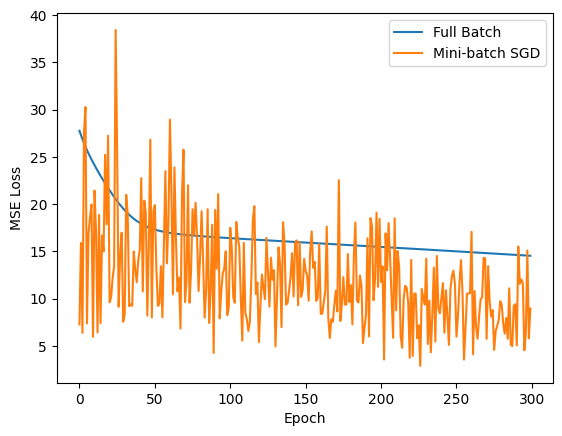

In [171]:
plt.plot(losses_full, label='Full Batch')
plt.plot(losses_sgd, label='Mini-batch SGD')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.show()

Above, we see that mini-batch SGD is much less stable here but appears to be approaching a better minimum faster in terms of epochs.

Now remember that mini-batch SGD can be very noisy.  We want some noise to escape local minimas, but we don't want to frequently change directions.  Instead of doing a fully new gradient update each time, we can use momentum.  With momentum instead of doing:

$$\theta^{t+1}=\theta^t-\eta\nabla\mathcal{L}$$

we do:

$$\theta^{t+1}=\theta^t-\eta v_t \\ \text{where } v_t = \gamma v_{t-1}+ \nabla \mathcal{L}(\theta^t)$$

We set the $\gamma$ parameter to $0.9$ here, meaning we keep 90% of the previous gradient update for the current update so that we do not change our direction quite as much.  Note also that the previous gradient here was a function of the gradient before it, and so it is like we are taking an average of all the past gradients but weighting recent ones more.  This also has an effect where if the gradients are pointing the same way we "speed up."  In practice this typically smooths and accelerates the process by using the past directions without losing the noise that we want or the efficiency.  

Below we fit a model using no momemntum and using momentum where $\gamma = 0.9$.



In [172]:
model_no_momentum = nn.Sequential(
    nn.Linear(1, 100),
    nn.ReLU(),
    nn.Linear(100, 100),
    nn.ReLU(),
    nn.Linear(100, 1)
)

optimizer = torch.optim.SGD(model_no_momentum.parameters(), lr=0.01)
criterion = nn.MSELoss()

losses_no_momentum = []

for epoch in range(125):
    y_hat = model_no_momentum(X_train)
    loss = criterion(y_hat, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses_no_momentum.append(loss.item())

In [173]:
model_momentum = nn.Sequential(
    nn.Linear(1, 100),
    nn.ReLU(),
    nn.Linear(100, 100),
    nn.ReLU(),
    nn.Linear(100, 1)
)

optimizer = torch.optim.SGD(model_momentum.parameters(), lr=0.01, momentum=0.9) # set gamma to 0.9
criterion = nn.MSELoss()

losses_momentum = []

for epoch in range(125):
    y_hat = model_momentum(X_train)
    loss = criterion(y_hat, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses_momentum.append(loss.item())

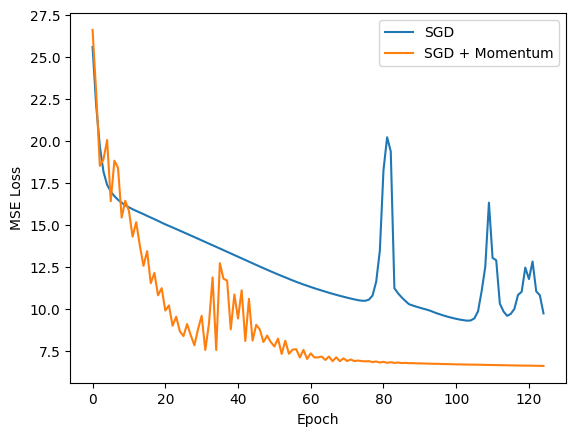

In [174]:
plt.plot(losses_no_momentum, label='SGD')
plt.plot(losses_momentum, label='SGD + Momentum')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.show()

Last we look at some forms of regularization.  The first model uses no regularization.  

Weight decay has been seen before, Ridge is the case of using weight decay on linear regression.  In pytorch weight decay is just adding a penalty term to the loss that is the sum of squared weights times $\lambda/2$.  Here we set $\lambda = 0.4$ for the second model.  

Dropout is new and specific to neural networks.  Dropout works by randomly setting some neuron outputs to $0$ during training with probability $p$.  The other neuron outputs are then scaled relatively (divided by $1-p$) to keep the expected output size roughly the same.  This helps the model not overly rely on certain neurons and therefore can improve generalization.  Put another way, if the neurons can randomly be turned off, the model should want some redundancy throughout which tends to help against over-fitting and too much pattern memorization as the model cannot rely on hyper-specialized neurons as much.  

In the example below the second model has dropout for each hidden layer set to $0.1$.  Note that with dropout, we have to be careful for when the model is set to train or eval mode as that enables/disables the dropout.  We only want dropout enabled for training purposes.

In [175]:
torch.manual_seed(801)
model_no_dropout = nn.Sequential(
    nn.Linear(1, 200),
    nn.ReLU(),
    nn.Linear(200, 200),
    nn.ReLU(),
    nn.Linear(200, 1)
)

In [176]:
torch.manual_seed(801)
model_dropout = nn.Sequential(
    nn.Linear(1, 200),
    nn.ReLU(),
    nn.Dropout(0.1), # set dropout to 0.1
    nn.Linear(200, 200),
    nn.ReLU(),
    nn.Dropout(0.1), # set dropout to 0.1
    nn.Linear(200, 1)
)

In [177]:
torch.manual_seed(801)
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model_no_dropout.parameters(), lr=0.001)

train_losses_no_dropout = []
val_losses_no_dropout = []

for epoch in range(2500):
    model_no_dropout.train()

    y_hat = model_no_dropout(X_train)
    loss = criterion(y_hat, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model_no_dropout.eval()
    with torch.no_grad():
        train_loss = criterion(model_no_dropout(X_train), y_train)
        val_loss = criterion(model_no_dropout(X_val), y_val)

    train_losses_no_dropout.append(train_loss.item())
    val_losses_no_dropout.append(val_loss.item())

In [178]:
torch.manual_seed(801)
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model_dropout.parameters(), lr=0.001, weight_decay=0.4)

train_losses_dropout = []
val_losses_dropout = []

for epoch in range(2500):
    model_dropout.train() # actually matters here

    y_hat = model_dropout(X_train)
    loss = criterion(y_hat, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model_dropout.eval() # actually matters here
    with torch.no_grad():
        train_loss = criterion(model_dropout(X_train), y_train)
        val_loss = criterion(model_dropout(X_val), y_val)

    train_losses_dropout.append(train_loss.item())
    val_losses_dropout.append(val_loss.item())

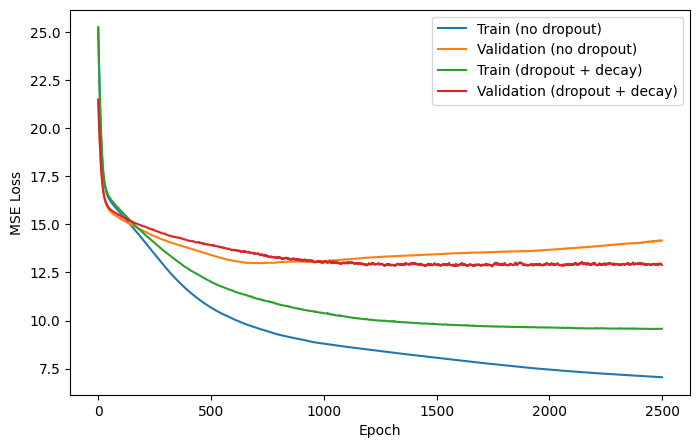

In [179]:
plt.figure(figsize=(8,5))
plt.plot(train_losses_no_dropout, label='Train (no dropout)')
plt.plot(val_losses_no_dropout, label='Validation (no dropout)')
plt.plot(train_losses_dropout, label='Train (dropout + decay)')
plt.plot(val_losses_dropout, label='Validation (dropout + decay)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

The setup here is not an ideal one for showcasing how regularization (especially dropout) can help, but we see that with regularization our training loss tends to be higher while our validation loss eventually becomes lower and does not start increasing notably.  

Here is the plot of both models.  We see that the one with no dropout or weight decay is much "bendier" as to be expected.  

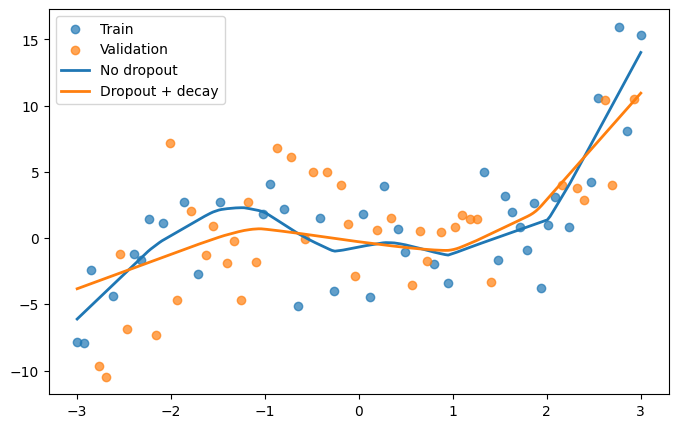

In [180]:
X_plot = torch.linspace(-3, 3, 200).reshape(-1, 1)

model_no_dropout.eval()
model_dropout.eval()

with torch.no_grad():
    y_plot_no_dropout = model_no_dropout(X_plot)
    y_plot_dropout = model_dropout(X_plot)

plt.figure(figsize=(8,5))
plt.scatter(X_train.numpy(), y_train.numpy(), label='Train', alpha=0.7)
plt.scatter(X_val.numpy(), y_val.numpy(), label='Validation', alpha=0.7)
plt.plot(X_plot.numpy(), y_plot_no_dropout.numpy(), label='No dropout', linewidth=2)
plt.plot(X_plot.numpy(), y_plot_dropout.numpy(), label='Dropout + decay', linewidth=2)
plt.legend()
plt.show()

Conceptual Questions:

1.  Why do larger neural networks (wider or deeper) tend to overfit more easily?  

2.  Why does overfitting usually start to happen later in the training rather than earlier?

3.  Why does dropout typically increase training loss?

4.  Why does dropout encourage more "robustness" in the model?

5.  Why does dropout tend to work better in large neural networks than small ones?

6.  What happens if we set dropout too large?

7.  Why is some noise in our gradient updates often beneficial?

8.  Why might full batch gradient descent actually generalize worse than mini-batch?

9.  How does momentum help prevent oscillation (zig-zagging)?

10.  How can momentum speed up training?

